# Import Library

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Bidirectional, SimpleRNN
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import StandardScaler

# Global Variables

In [2]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 0.001

# Load Data

In [3]:
train_df = pd.read_csv('Data/DailyDelhiClimateTrain.csv', parse_dates=['date'])
test_df = pd.read_csv('Data/DailyDelhiClimateTest.csv', parse_dates=['date'])

train_df.set_index('date', inplace=True)
test_df.set_index('date', inplace=True)

# EDA

In [4]:
train_df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
test_df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333


## Visualize Data

### Train

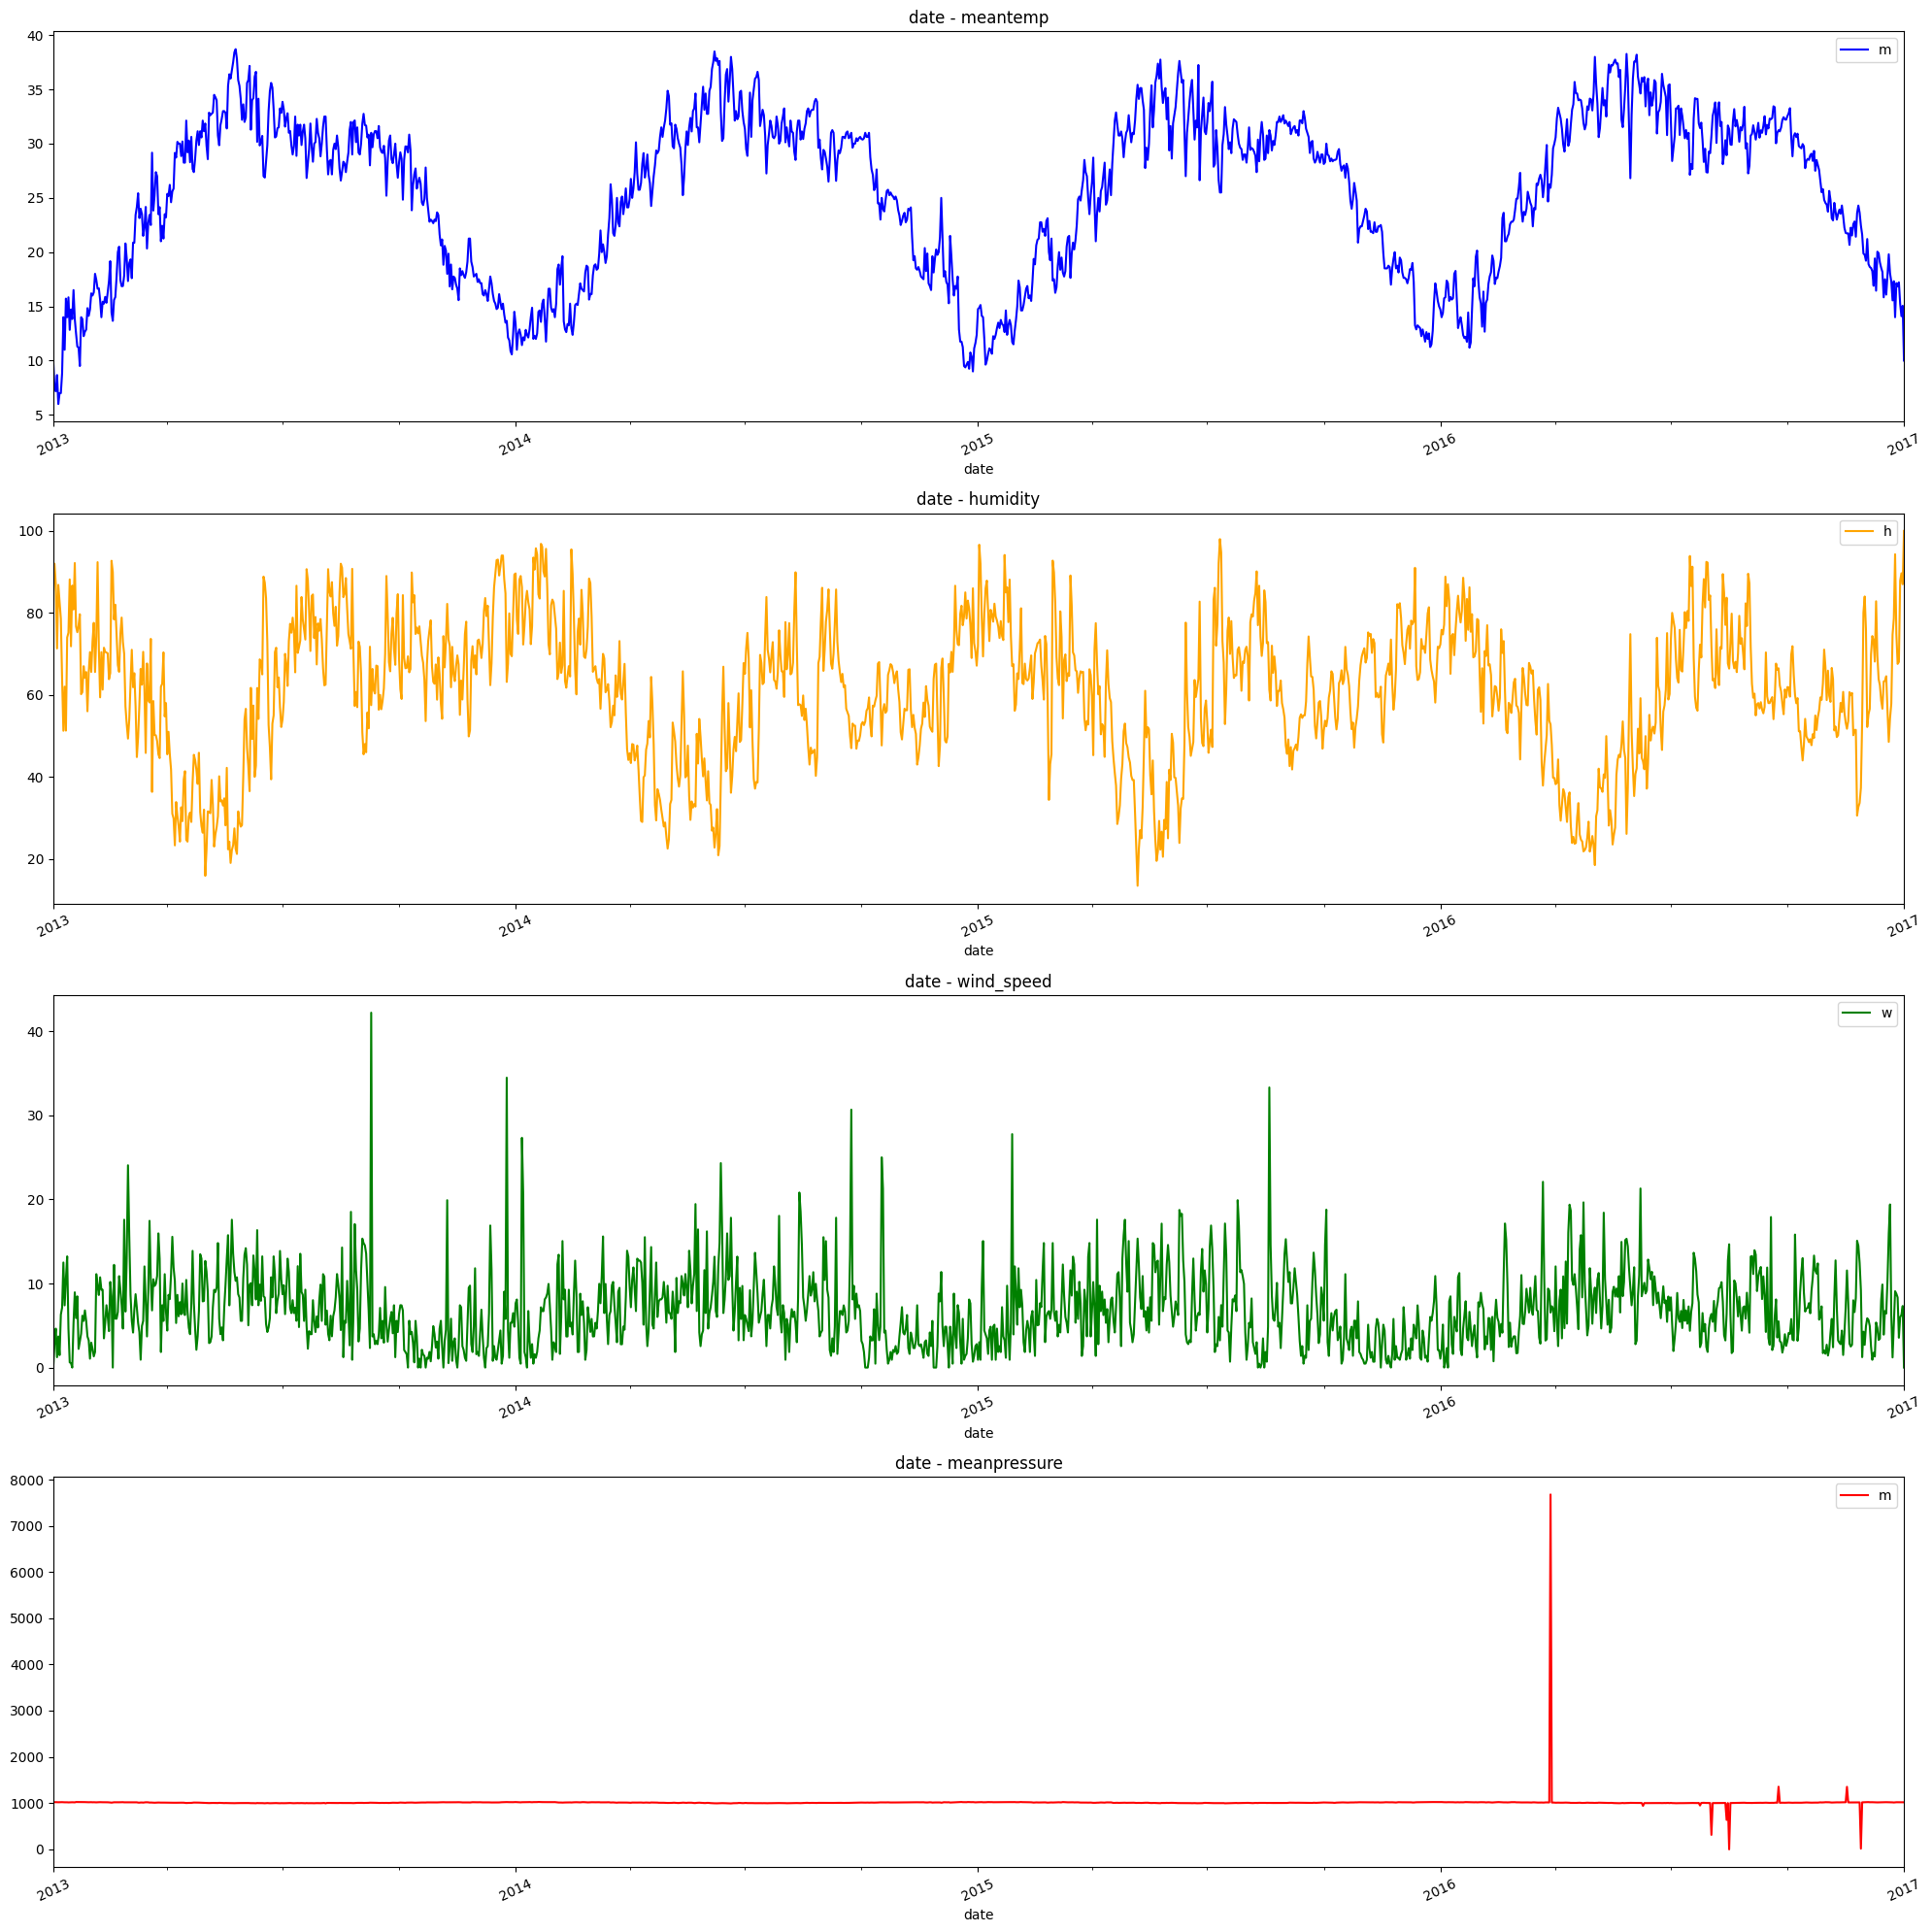

In [6]:
COLORS = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]

def create_vizualizations(data : pd.DataFrame):
    columns = list(data.columns)
    x = data.index
    fig, axes = plt.subplots(nrows=len(columns), ncols=1, figsize=(20, 20), facecolor='w', edgecolor='k')
    for idx, col in enumerate(columns):
        ax = data[col].plot(ax=axes[idx], color=COLORS[idx], title=f'{x.name} - {col}', rot=25)
        ax.legend(col)
    plt.tight_layout()

create_vizualizations(train_df)

### Test

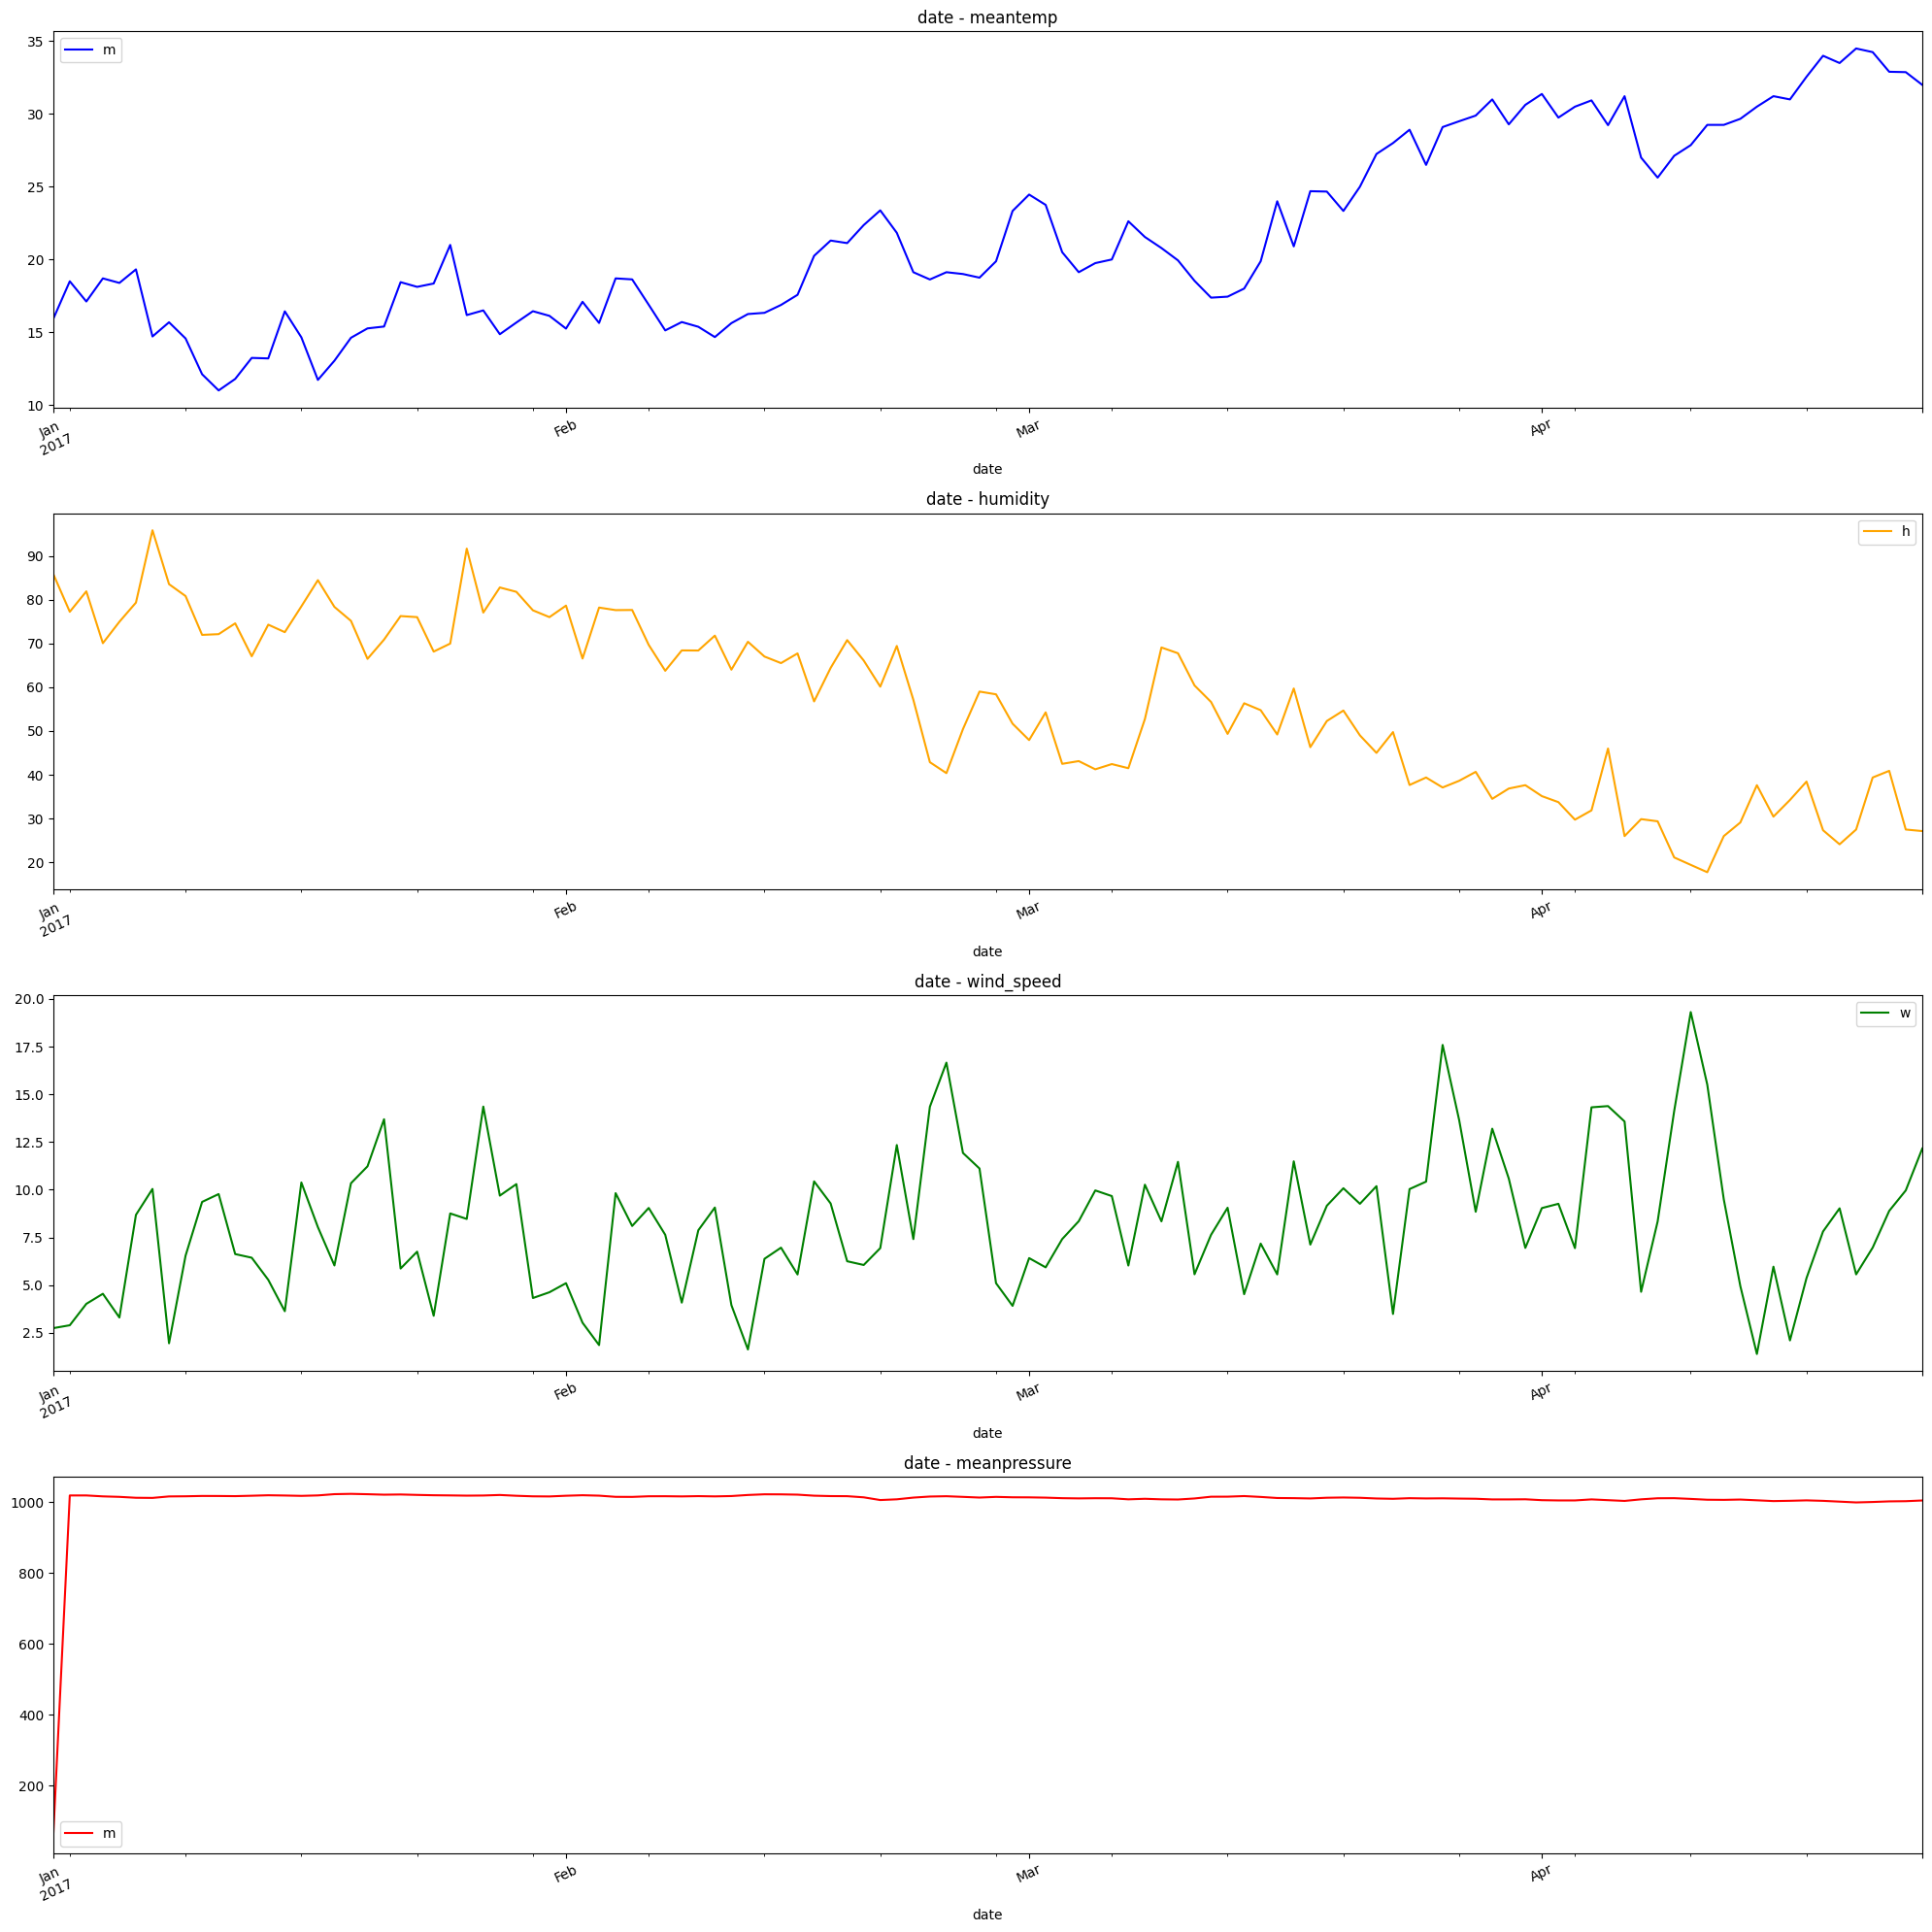

In [7]:
create_vizualizations(test_df)

# Preprocessing

## Split Data (Train, Validation)

In [8]:
from sklearn.model_selection import train_test_split

X_train = train_df.values.tolist()
# X_train = np.array(train_df, dtype='float32')

class normalize:
    def __init__(self, data):
        self.data = np.array(data, dtype='float32')
        self.mean = self.data.mean(axis=0)
        self.std = self.data.std(axis=0)
    
    def __call__(self):
        return list((self.data - self.mean)/self.std)
    
    def inverse(self, data):
        return list(data*self.std + self.mean)

normalizer = normalize(X_train)

X_train = normalizer()

def create_instances(data, window : int = 1, future : int = 1):
    X, y = [], []
    for i in range(len(data)-window-future):
        feature = data[i : i+window]
        # target = data[i+future+1 : i+window+future+1]
        target = data[i+window+future]
        X.append(feature)
        y.append(target)
    return X, y

window = 5
future = 3
X_train, y_train = create_instances(X_train, window=window, future=future)

split_fraction = 0.2
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=split_fraction, random_state=42)
X_train, X_val, y_train, y_val = np.array(X_train), np.array(X_val), np.array(y_train), np.array(y_val)
print(f"Train split : {X_train.shape}\t{y_train.shape}\nVal split : {X_val.shape}\t{y_val.shape}")

Train split : (1163, 5, 4)	(1163, 4)
Val split : (291, 5, 4)	(291, 4)


## Convert Data to Tensor

In [9]:
BUFFER_SIZE = 10000
EVALUATION_INTERVAL = 200

train_data_single = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

# Model (LSTM)

## Model Structure

In [10]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=20, return_sequences=True)(i)
    x = Dropout(0.2)(x)
    x = LSTM(units=20)(x)
    x = Dropout(0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(4)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [11]:
Model1 = create_model(X_train.shape[1], X_train.shape[2])

In [12]:
Model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 4)]            0         
                                                                 
 lstm (LSTM)                 (None, 5, 20)             2000      
                                                                 
 dropout (Dropout)           (None, 5, 20)             0         
                                                                 
 lstm_1 (LSTM)               (None, 20)                3280      
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 batch_normalization (BatchN  (None, 20)               80        
 ormalization)                                                   
                                                             

## Compile Model

In [13]:
Model1.compile(optimizer=RMSprop(), loss=MeanAbsoluteError())

## Train Model

In [14]:
checkpointer = ModelCheckpoint(filepath = 'weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

his_model1=Model1.fit(train_data_single, 
               steps_per_epoch=EVALUATION_INTERVAL, 
               epochs=EPOCHS, 
               validation_data=val_data_single, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping],
               validation_steps=50)

Epoch 1/100
200/200 [==============================] - ETA: 0s - loss: 0.6103
Epoch 1: val_loss improved from inf to 0.56073, saving model to weights_best.hdf5
200/200 [==============================] - 8s 14ms/step - loss: 0.6103 - val_loss: 0.5607
Epoch 2/100
196/200 [============================>.] - ETA: 0s - loss: 0.4904
Epoch 2: val_loss improved from 0.56073 to 0.51349, saving model to weights_best.hdf5
200/200 [==============================] - 2s 12ms/step - loss: 0.4906 - val_loss: 0.5135
Epoch 3/100
195/200 [============================>.] - ETA: 0s - loss: 0.4486
Epoch 3: val_loss improved from 0.51349 to 0.43553, saving model to weights_best.hdf5
200/200 [==============================] - 2s 12ms/step - loss: 0.4513 - val_loss: 0.4355
Epoch 4/100
197/200 [============================>.] - ETA: 0s - loss: 0.4283
Epoch 4: val_loss improved from 0.43553 to 0.39999, saving model to weights_best.hdf5
200/200 [==============================] - 2s 12ms/step - loss: 0.4274 - val_l

## Load Best Weights

In [15]:
Model1.load_weights('weights_best.hdf5')

# Evaluation

## Preprocess Test Data

In [62]:
X_test = test_df.values.tolist()
# X_test = np.array(test_df, dtype='float32')

test_normalizer = normalize(X_test)
X_test = test_normalizer()

window = 5
future = 3
X_test, y_test = create_instances(X_test, window=window, future=future)
X_test, y_test = np.array(X_test), np.array(y_test)
print(f"Test split : {X_test.shape}\t{y_test.shape}")

Test split : (106, 5, 4)	(106, 4)


In [63]:
test_data_single = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_data_single = test_data_single.batch(BATCH_SIZE).repeat()

In [64]:
Model1.evaluate(test_data_single, steps=50)

 1/50 [..............................] - ETA: 0s - loss: 0.3812

50/50 [==============================] - 0s 5ms/step - loss: 0.4172


0.4171540439128876

In [65]:
# Calculate the inversed mean absolute error
y_pred = Model1.predict(X_test)

y_pred = np.array(test_normalizer.inverse(y_pred))
y_test = np.array(test_normalizer.inverse(y_test))

mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error : {mae}")

# Calculate the mean absolute error for each column
## Mean Temp
mae = np.mean(np.abs(y_test[:, 0] - y_pred[:, 0]))
print(f"Mean Humidity MAE : {mae}")

## Humidity
mae = np.mean(np.abs(y_test[:, 1] - y_pred[:, 1]))
print(f"Mean Humidity MAE : {mae}")

## Wind Speed
mae = np.mean(np.abs(y_test[:, 2] - y_pred[:, 2]))
print(f"Mean Wind Speed MAE : {mae}")

## Mean Pressure
mae = np.mean(np.abs(y_test[:, 3] - y_pred[:, 3]))
print(f"Mean Pressure MAE : {mae}")

4/4 [==============================] - 0s 5ms/step
Mean Absolute Error : 5.583823204040527
Mean Humidity MAE : 2.6121890544891357
Mean Humidity MAE : 7.886137008666992
Mean Wind Speed MAE : 2.6456494331359863
Mean Pressure MAE : 9.191316604614258


The model is not a good fit for the data as the prediction deviated from the actual data. The model can be improved by increasing the number of layers, increasing the number of units, and increasing the number of epochs. With deviation stated above, the model is not a good fit for the data.

## Visualize Train and Validation Loss

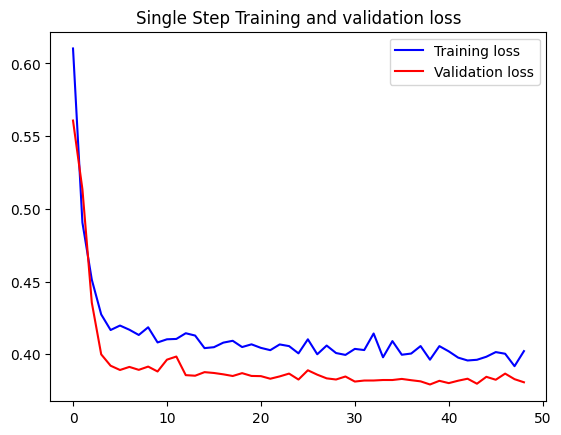

In [19]:
def plot_train_history(history, title):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(loss))

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.legend()

    plt.show()
    
plot_train_history(his_model1, 'Single Step Training and validation loss')

The model is training nicely as it's reaching for convergence

## Inference

In [20]:
y_test_pred = Model1.predict(X_test)

10/10 [==============================] - 0s 3ms/step


In [39]:
# Create an inference plot based on the model for each of the columns
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return

    

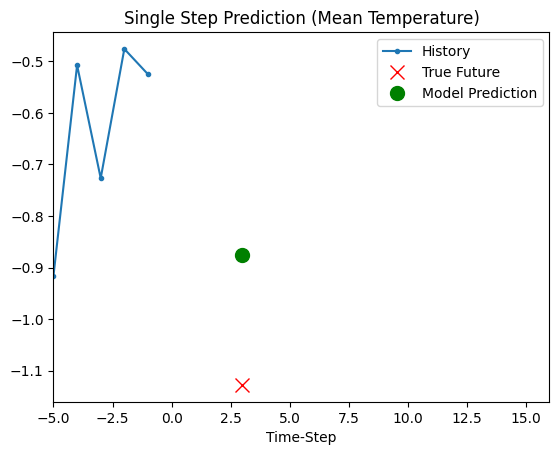

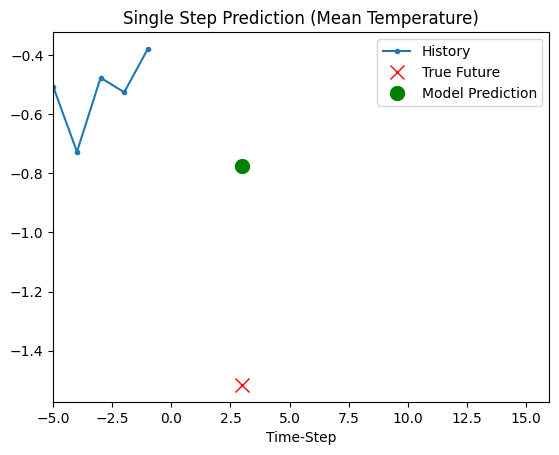

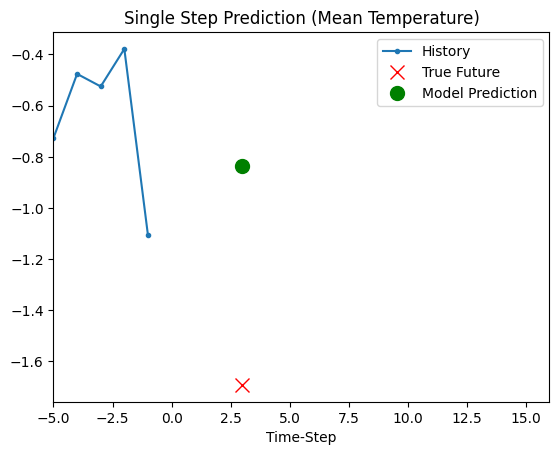

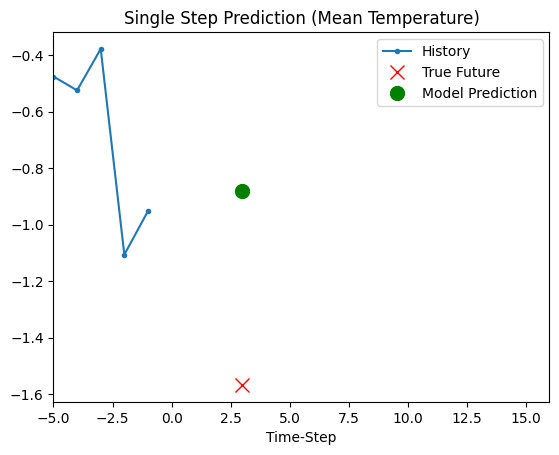

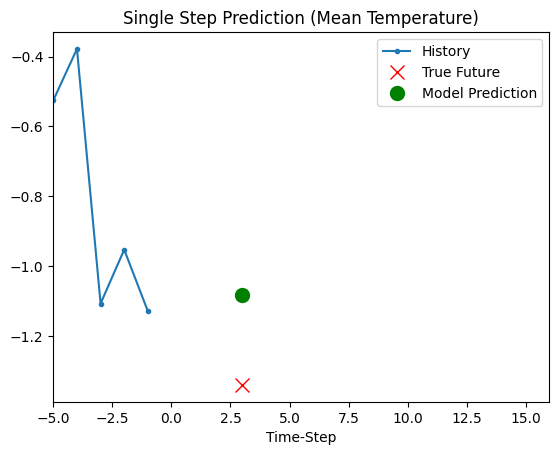

In [44]:
for i in range(0, 5):
    show_plot([X_test[i][:, 0], y_test[i][0], y_test_pred[i][0]], future, 'Single Step Prediction (Mean Temperature)')

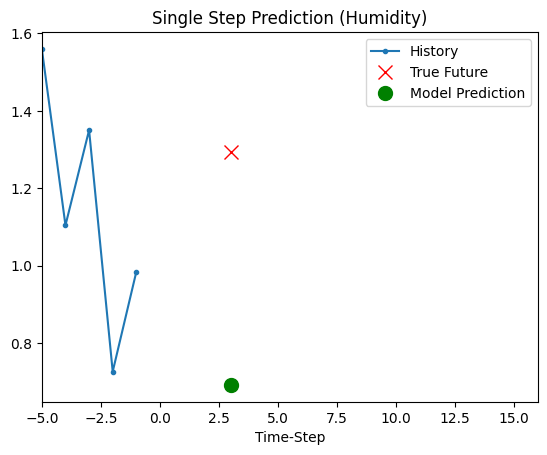

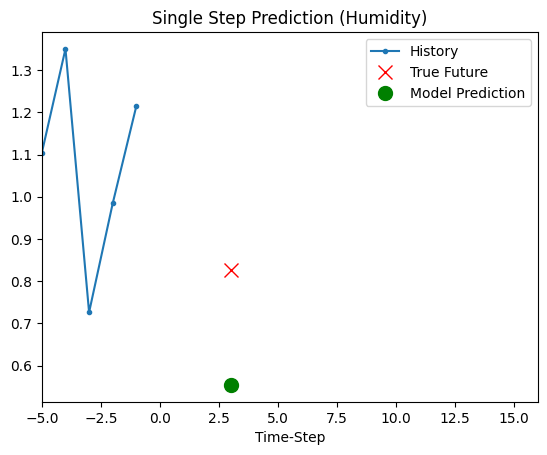

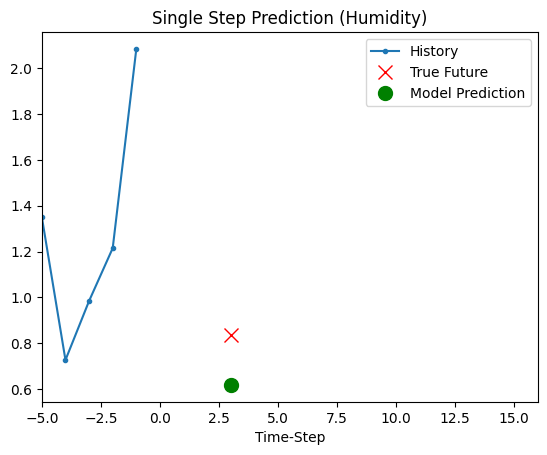

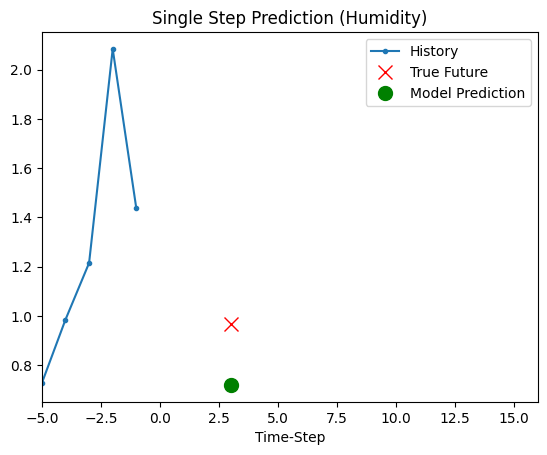

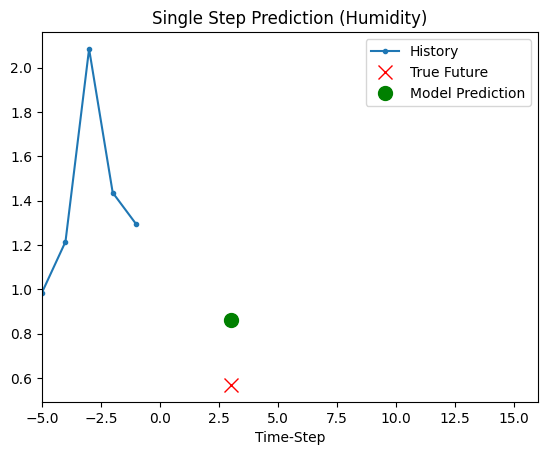

In [45]:
for i in range(0, 5):
    show_plot([X_test[i][:, 1], y_test[i][1], y_test_pred[i][1]], future, 'Single Step Prediction (Humidity)')

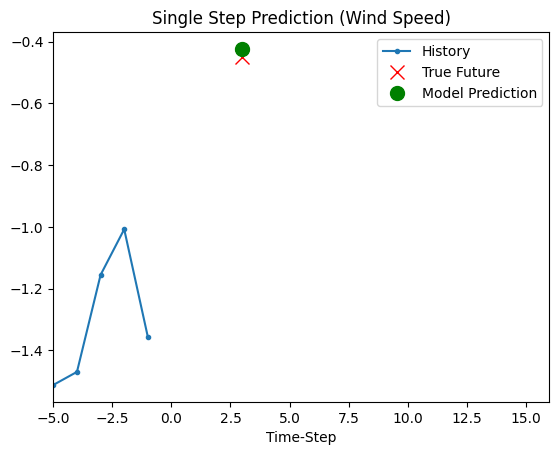

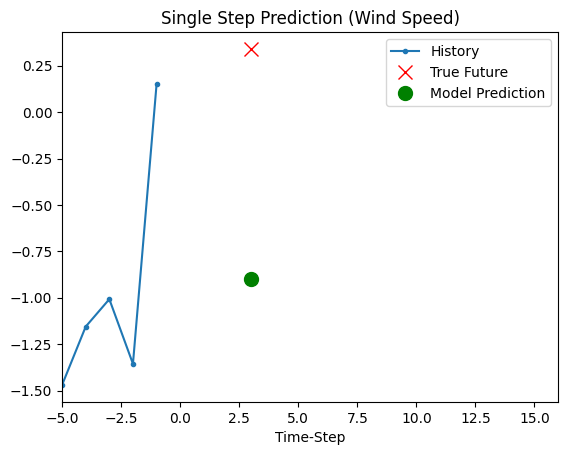

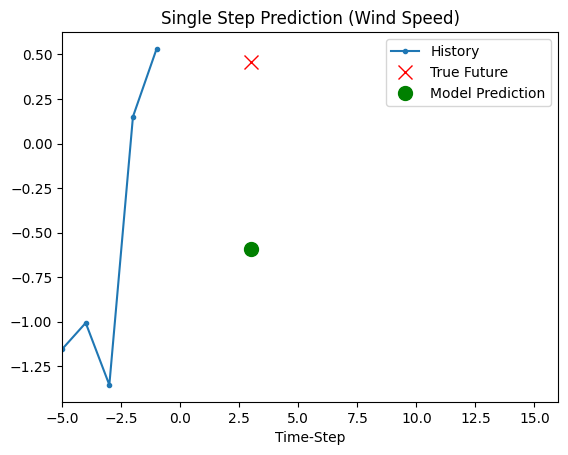

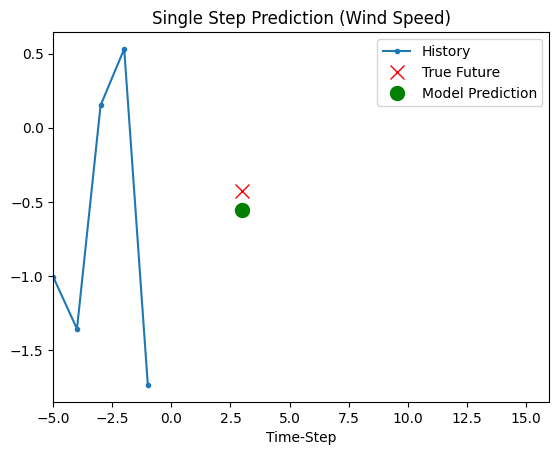

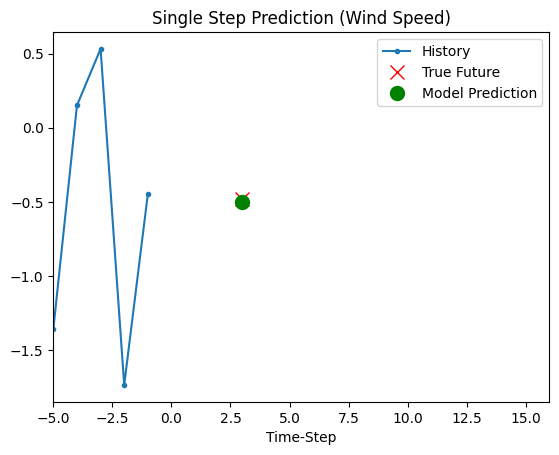

In [46]:
for i in range(0, 5):
    show_plot([X_test[i][:, 2], y_test[i][2], y_test_pred[i][2]], future, 'Single Step Prediction (Wind Speed)')

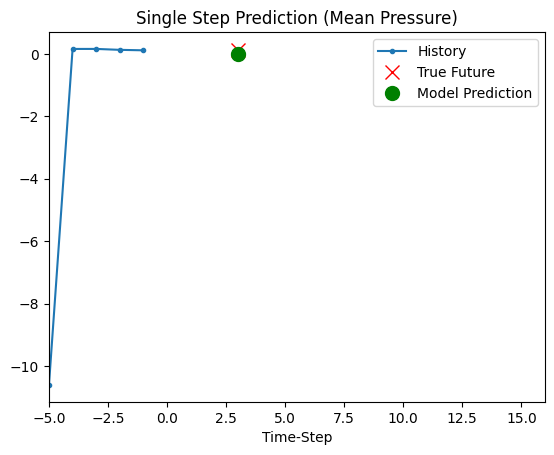

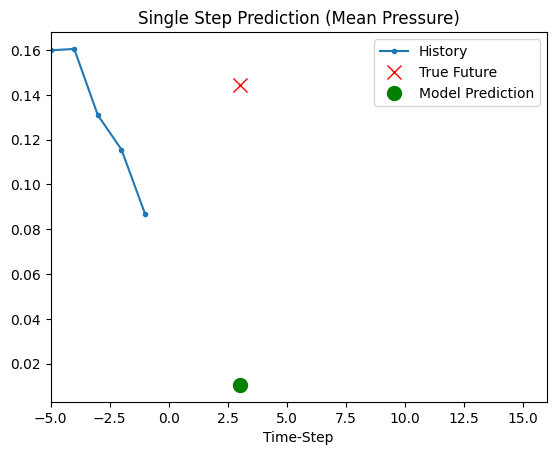

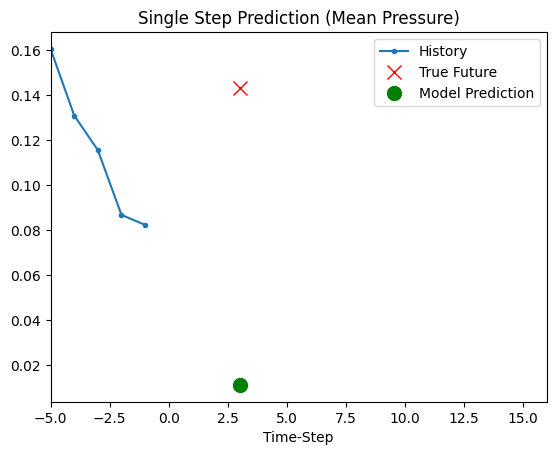

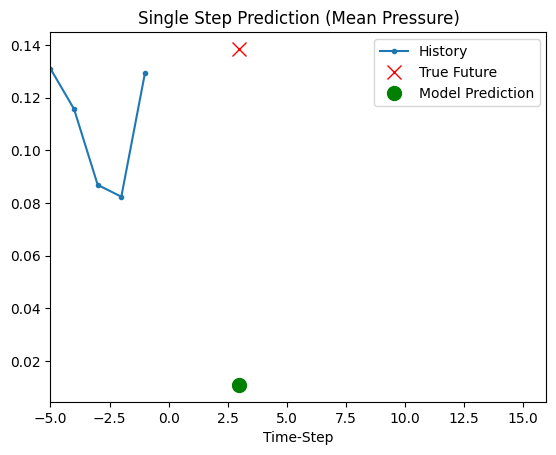

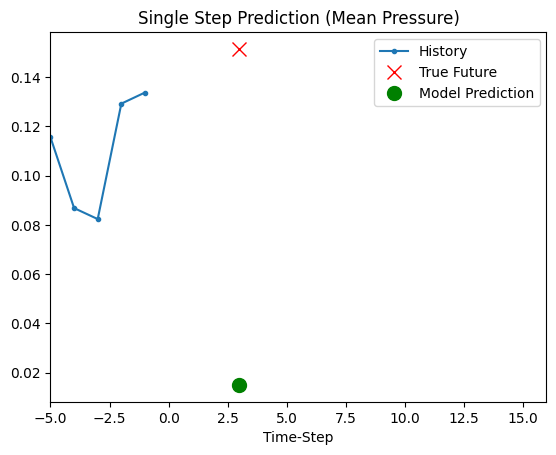

In [47]:
for i in range(0, 5):
    show_plot([X_test[i][:, 3], y_test[i][3], y_test_pred[i][3]], future, 'Single Step Prediction (Mean Pressure)')

# Conclusion

The model is on average not a good fit for the data with a average MAE of 5. The model can be improve by implementing backbone or increasing the number of layers, units, and epochs thus creating a more complex model.